# Product Name Normalization & Feature Extraction

Pipeline to extract structural components and normalize product names for matching:
1. Supermarket brand extraction & removal
2. Tier classification (extract but keep in name)
3. Known brand detection
4. Multipack/pack size extraction
5. Unit extraction & standardization (g/ml/mg)
6. Attribute extraction
7. Core & normalized name generation

In [16]:
# Setup and Data Loading

import pandas as pd
import numpy as np
import re
import unicodedata
from typing import Tuple, List, Dict, Optional
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('data/raw.csv')
initial_count = len(df)

# Remove empty product names
df = df[df['names'].notna() & (df['names'].str.strip() != '')].reset_index(drop=True)

print(f"Dataset loaded: {df.shape}")
print(f"Removed: {initial_count - len(df)} empty names")
print(f"Columns: {list(df.columns)}")

Dataset loaded: (65472, 8)
Removed: 1 empty names
Columns: ['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date', 'category', 'own_brand']


In [27]:
## 1. Define Extraction Patterns and Vocabularies

# Supermarket-specific brand prefixes (ordered by length for proper matching)
SUPERMARKET_BRANDS = {
    'Tesco': [
        'Tesco Finest',
        'Tesco Everyday Value', 
        'Tesco Free From',
        'Tesco Organic',
        'Tesco',
    ],
    'ASDA': [
        'ASDA Extra Special',
        'Asda Extra Special',
        'ASDA Smart Price',
        'Asda Smart Price',
        'ASDA Chosen By You',
        'Asda Chosen By You',
        'ASDA Free From',
        'Asda Free From',
        'ASDA',
        'Asda',
    ],
    'Morrisons': [
        'Morrisons The Best',
        'Morrisons Savers',
        'Morrisons Free From',
        'Morrisons Organic',
        'M Kitchen',
        'Morrisons',
    ],
    'Sains': [
        'Sainsbury\'s Taste the Difference',
        'Sainsburys Taste the Difference',
        'Taste the Difference',
        'Sainsbury\'s Basics',
        'Sainsburys Basics',
        'Sainsbury\'s Free From',
        'Sainsburys Free From',
        'SO Organic',
        'Sainsbury\'s',
        'Sainsburys',
    ]
}

# Quality and Value tier keywords
QUALITY_TIERS = {
    'premium': ['finest', 'extra special', 'taste the difference', 'the best', 'premium', 
                'luxury', 'deluxe', 'superior', 'select'],
    'value': ['value', 'basics', 'savers', 'smart price', 'everyday value', 'everyday', 
              'essential', 'essentials']
}

# Well-known commercial brands (comprehensive list)
KNOWN_BRANDS = [
    # Beverages (soft drinks, water, juice)
    'coca-cola', 'coca cola', 'pepsi', 'fanta', 'sprite', 'dr pepper', '7up', 'schweppes',
    'ribena', 'robinsons', 'tropicana', 'innocent', 'capri sun', 'vimto', 'lucozade',
    'red bull', 'monster', 'relentless',

    # Coffee & Tea
    'nescafe', 'twinings', 'tetley', 'pg tips', 'yorkshire tea', 'clipper', 'pukka',
    'costa', 'starbucks', 'lavazza', 'illy', 'kenco', 'douwe egberts', 'tassimo',

    # Dairy & chilled
    'anchor', 'lurpak', 'flora', 'benecol', 'philadelphia', 'dairylea', 'babybel',
    'muller', 'müller', 'yoplait', 'activia', 'danone', 'alpro', 'oatly',

    # Core food brands
    'heinz', 'kellogg\'s', 'kelloggs', 'nestle', 'cadbury', 'mars', 'snickers',
    'walkers', 'pringles', 'doritos', 'mccoys', 'quavers', 'wotsits',
    'ben & jerry\'s', 'ben & jerrys', 'haagen-dazs', 'haagen dazs',
    'warburtons', 'hovis', 'kingsmill', 'allinson',
    'uncle ben\'s', 'uncle bens', 'dolmio', 'loyd grossman',
    'sharwood\'s', 'sharwoods', 'pataks', 'blue dragon',
    'birdseye', 'birds eye', 'aunt bessie\'s', 'aunt bessies',
    'youngs', 'john west', 'princes',
    'pukka pies', 'charlie bigham\'s', 'charlie bighams',
    'quorn', 'linda mccartney', 'richmond',

    # Household & personal care
    'andrex', 'kleenex', 'regina', 'cushelle',
    'persil', 'ariel', 'fairy', 'comfort', 'lenor',
    'colgate', 'gillette', 'dove', 'nivea',
    'paxo', 'bisto', 'oxo', 'knorr', 'maggi',
    'branston', 'colman\'s', 'colmans', 'marmite', 'bovril',

    # ------------------------------------------------------------------
    # Additional UK supermarket brands (food & drink focused)
    # ------------------------------------------------------------------

    # Soft drinks, water, juice
    'irn bru', 'irn-bru',
    'oasis',
    'rubicon',
    'tango',
    'ka',
    'rio',
    'ocean spray',
    'san pellegrino', 'sanpellegrino',
    'evian',
    'volvic',
    'buxton',
    'highland spring',
    'vittel',
    'mountain dew',
    'dr witt',
    'frobishers',
    'barr', 'barrs',   # a.g. barr (often appears as barr)
    'robicon',  # occasional misspelling in data

    # Energy & sports drinks
    'rockstar',
    'eos energy',   # smaller energy brands often show up
    'boost energy', 'boost',

    # Flavoured milk & dairy drinks
    'yazoo',
    'frijj',
    'nesquik',
    'actimel',
    'milkshake man',  # challenger brands occasionally appear

    # Coffee pods & ground coffee
    'nespresso',
    'dolce gusto',
    'taylors of harrogate', 'taylors',
    'cafe direct', 'cafedirect',
    'maxwell house',
    'lavazza tierra',  # sub-brand but appears in titles
    'illy intenso',    # ditto

    # Tea (additional)
    'barrys tea', 'barry\'s tea',
    'tick tock',       # rooibos
    'dragonfly tea',

    # Milk, butter, cheese, yogurt & plant-based
    'cathedral city',
    'yeo valley',
    'country life',
    'clover',
    'kerrygold',
    'cravendale',
    'elmlea',
    'president', 'président',
    'castello',
    'onken',
    'ski',
    'actimel',   # keep for robustness
    'glenisk',
    'provamel',
    'soya delight',
    'violife',
    'follow your heart',
    'nutricia',
    'almond breeze',
    'rude health',

    # Breakfast cereals & cereal bars
    'weetabix',
    'weetabix minis',
    'oatibix',
    'alpen',
    'jordans',
    'ready brek',
    'shreddies',
    'cheerios',
    'shredded wheat',
    'curiously cinnamon',
    'cookie crisp',
    'weetos',
    'special k',
    'corn flakes',
    'rice krispies',
    'coco pops',
    'frosties',
    'bear',          # cereal/snack brand
    'nature valley',
    'belvita',
    'nakd',
    'trek',
    'kind',

    # Bread, bakery, cakes
    'mcvitie\'s', 'mcvities',
    'jacob\'s', 'jacobs',
    'fox\'s', 'foxs',
    'mr kipling',
    'border biscuits', 'border',
    'tunnock\'s', 'tunnocks',
    'maryland',
    'go ahead', 'go-ahead',
    'hobnobs',
    'chocolate fingers',  # usually under cadbury but appears as token
    'carr\'s', 'carrs',
    'frank\'s biscuits',  # long-tail brand
    'pop tarts', 'pop-tarts',
    'lotus biscoff', 'biscoff',
    'jacquet',

    # Biscuits, sweets, chocolate
    'galaxy',
    'lindt',
    'thorntons',
    'green & black\'s', 'green and blacks', 'green & blacks',
    'ferrero rocher', 'ferrero',
    'toblerone',
    'after eight', 'after-eights', 'after eights',
    'maltesers',
    'm&ms', 'm and ms', 'm&m\'s',
    'bounty',
    'milky way',
    'twix',
    'kit kat', 'kitkat',
    'rowntree\'s', 'rowntrees',
    'haribo',
    'maynards bassetts', 'maynards', 'bassetts',
    'opalc fruit',  # noisy misspelling variants
    'swizzels', 'swizzels matlow',
    'wine gums',    # often appears standalone
    'jelly tots',
    'jelly babies',
    'jelly belly',

    # Crisps & savoury snacks
    'kettle', 'kettle chips',
    'tyrrells',
    'seabrook',
    'pom-bear', 'pombear',
    'hula hoops', 'hulahoops',
    'skips',
    'discos',
    'nik naks', 'niknaks',
    'frazzles',
    'monster munch', 'monstermunch',
    'popchips',
    'sunbites',
    'propercorn', 'proper snacks', 'properchips',
    'metcalfe\'s', 'metcalfes',
    'snack a jacks', 'snackajacks',
    'mini cheddars',

    # Rice, grains, pasta & noodles
    'ben\'s original', 'bens original',
    'tilda',
    'laila',
    'gallo',
    'risella',
    'merchant gourmet',
    'barilla',
    'de cecco', 'dececco',
    'napolina',
    'batchelors',
    'itsu',          # rice & noodle bowls
    'yutaka',
    'amoy',
    'shoryu',
    'soba',          # some chilled lines use this as brand token

    # Tins, jars, pickles, ambient
    'green giant',
    'cirio',
    'la doria', 'ladoria',
    'glenryck',
    'sacla',
    'mutti',
    'fray bentos',
    'princes fruit',
    'rizla',   # ignore – non-food but often appears
    'kallo',
    'baxters',
    'hartley\'s', 'hartleys',
    'tiptree',
    'robertson\'s', 'robertsons',
    'duerr\'s', 'duerrs',
    'bonne maman',
    'rowse',
    'st dalfour', 'st. dalfour',
    'geo organics',
    'biona',
    'whole earth',
    'meridian',
    'sun-pat', 'sun pat',
    'skippy',
    'nutella',

    # Cooking sauces, world food, condiments
    'hellmann\'s', 'hellmanns',
    'hp sauce', 'hp',
    'lea & perrins', 'lea and perrins',
    'frank\'s redhot', 'franks redhot', 'frank\'s', 'franks',
    'tabasco',
    'encona',
    'cholula',
    'sriracha', 'flying goose',
    'kikkoman',
    'lee kum kee',
    'amoy',
    'itsu',
    'blue dragon',   # already above but keep for robustness in parsing
    'old el paso',
    'santa maria',
    'geeta\'s', 'geetas',
    'rajah',
    'shito',         # ghanaian sauce brand tokens sometimes

    # Frozen foods & ready meals
    'mccain',
    'goodfella\'s', 'goodfellas',
    'dr oetker', 'dr. oetker',
    'chicago town',
    'rustlers',
    'birds eye steamfresh',  # often appears like a brand
    'aunt bessie\'s',        # already above but kept as variant
    'findus',
    'young\'s gastro',       # appears as sub-brand
    'strong roots',
    'cauldron',
    'tofoo', 'the tofoo co', 'the tofoo company',
    'beyond meat',
    'moving mountains',
    'this isn\'t', 'this',  # plant-based brand often in chilled/frozen

    # Chilled meat, sausages, bacon, pies
    'wall\'s', 'walls',
    'heck',
    'ye olde oak',
    'herta',
    'bernard matthews',
    'mattessons',
    'ginsters',
    'pukka pies',   # already above but common
    'fraser\'s',    # some regional brands appear
    'melton mowbray',  # often used like brand token on pork pies

    # Baby & toddler
    'cow & gate', 'cow and gate',
    'aptamil',
    'hipp', 'hipp organic',
    'ella\'s kitchen', 'ellas kitchen',
    'organix',
    'kiddylicious',
    'heinz by nature',
    'piccolo',
    'little freddie',

    # Pet food
    'whiskas',
    'felix',
    'sheba',
    'go-cat', 'gocat',
    'bakers',
    'pedigree',
    'winalot',
    'chappie',
    'cesar',
    'butcher\'s', 'butchers',
    'lily\'s kitchen', 'lilys kitchen',
    'iams', 'i\'ams',
    'royal canin',
    'purina one',
    'purina gourmet',
    'purina friskies', 'friskies',
    'webbox',
    'naturediet',

    # Household cleaning, laundry, dishwash
    'surf',
    'bold',
    'daz',
    'ace',
    'ecover',
    'method',
    'vanish',
    'dr beckmann', 'dr. beckmann',
    'dettol',
    'domestos',
    'flash',
    'mr muscle', 'mr. muscle',
    'cilit bang', 'cillit bang',
    'harpic',
    'toilet duck', 'duck',
    'finish',
    'powerball',   # often appended to finish
    'air wick', 'airwick',
    'glade',
    'febreze',
    'ambipur',
    'zoflora',

    # Toiletries, personal care
    'sure',
    'lynx',
    'rexona',
    'simple',
    'vaseline',
    'sanex',
    'radox',
    'carex',
    'palmolive',
    'imperial leather',
    'original source',
    'carex',
    'head & shoulders', 'head and shoulders',
    'herbal essences',
    'pantene',
    'tresemme', 'trèsseme',  # spelling noise
    'aussie',
    'oral-b', 'oral b',
    'sensodyne',
    'aquafresh',
    'listerine',
    'corsodyl',
    'garnier',
    'olay',
    'aveeno',
    'schwarzkopf',
    'got2b',

    # Paper products & hygiene
    'velvet',
    'velvet comfort',
    'lotus',
    'plenty',
    'bounty kitchen roll', 'bounty',
    'tork',

    # Sugar, baking, home baking
    'tate & lyle', 'tate and lyle', 'tate lyle',
    'silver spoon',
    'billington\'s', 'billingtons',
    'allinson\'s', 'allinsons',
    'homepride',
    'dr oetker baking',  # baking sub-brand
    'betty crocker',
    'doves farm',

    # Beer & Cider
    'stella artois', 'stella', 'budweiser', 'bud', 'heineken', 'carlsberg',
    'foster\'s', 'fosters', 'carling', 'kronenbourg', '1664',
    'peroni', 'birra moretti', 'moretti', 'san miguel', 'estrella', 'estrella damm',
    'guinness', 'john smith\'s', 'john smiths', 'boddingtons',
    'brewdog', 'camden town', 'camden hells', 'beavertown', 'neck oil',
    'strongbow', 'thatchers', 'kopparberg', 'magners', 'bulmers', 'old mout',
    'corona', 'desperados', 'beck\'s', 'becks',

    # Spirits (Gin, Vodka, Whisky, Rum)
    'smirnoff', 'absolut', 'grey goose', 'glen\'s', 'glens',
    'gordon\'s', 'gordons', 'bombay sapphire', 'tanqueray', 'hendrick\'s', 'hendricks', 'beefeater',
    'jack daniel\'s', 'jack daniels', 'jd', 'jim beam', 'maker\'s mark',
    'jameson', 'famous grouse', 'bell\'s', 'bells', 'johnnie walker', 'glenfiddich',
    'captain morgan', 'bacardi', 'havana club', 'malibu', 'kraken',
    'baileys', 'tia maria', 'kahlua', 'disaronno', 'southern comfort',
    'pimms', 'pimm\'s', 'martini', 'aperol', 'campari',
    'courvoisier', 'hennessy',

    # Wine & Champagne
    'hardys', 'blossom hill', 'yellow tail', 'casillero del diablo',
    'campo viejo', 'villa maria', 'oyster bay', '19 crimes', 'jam shed',
    'barefoot', 'gallo', 'mcguigan', 'jacob\'s creek', 'jacobs creek',
    'lindeman\'s', 'lindemans', 'wolf blass',
    'freixenet', 'moët', 'moet', 'veuve clicquot', 'bollinger', 'lanson',

    # ------------------------------------------------------------------
    # MISSING FOOD GIANTS
    # ------------------------------------------------------------------
    # Spices, Seasonings & Baking (Crucial for Pantry)
    'schwartz',             # The biggest spice brand in UK
    'bart',                 # Major spice brand
    'maldon',               # Salt
    'saxa',                 # Salt
    'sarson\'s', 'sarsons', # Vinegar
    'haywards',             # Pickles
    'whitworths',           # Dried fruit/baking (Found in your data snippets!)
    'nielsen-massey',       # Vanilla
    'filippo berio',        # Olive oil
    'bertolli',             # Olive oil/spread
    'crisp \'n dry',        # Oil
    'flora',                # Margarine

    # Confectionery & Snacking (Specifics missing from your list)
    'kinder', 'kinder bueno',
    'werther\'s', 'werthers',
    'tic tac',
    'mentos',
    'skittles',
    'starburst',
    'polo',
    'wrigley\'s', 'extra', 'airwaves', # Gum
    'chupa chups',
    'kp', 'kp nuts',        # Major nut brand
    'nobby\'s', 'nobbys',   # Nuts
    'planters',             # Nuts
    'graze',                # Healthy snacks
    'pladis',               # Parent co, sometimes appears
    'gü', 'gu',             # Puds (often listed as brand)

    # World Food & Noodles
    'pot noodle',           # Distinct from Unilever
    'super noodles',        # Batchelors sub-brand often standalone
    'nissin',               # Soba/Cup Noodles
    'kohinoor',             # Rice
    'tiana',                # Coconut products
    'blue dragon',          # (Check duplicates, but vital)
    'old el paso',          # (Check duplicates, but vital)

    # Meat Alternatives (Growing category)
    'meatless farm',
    'vivera',
    'this',                 # "THIS isn't chicken" etc
    'cauldron',

    # ------------------------------------------------------------------
    # MISSING BEVERAGES
    # ------------------------------------------------------------------
    'fever-tree', 'fever tree', # Premium mixers (Huge market share)
    'britvic',
    'j2o',
    'fruit shoot',
    'highland spring',      # Water
    'evian',                # Water
    'volvic',               # Water
    'twinings',             # Tea (Check duplicates)
    'tetley',               # Tea
]


# Attribute keywords
ATTRIBUTES = {
    'organic': ['organic', 'bio', 'soil association'],
    'free_from': ['gluten free', 'dairy free', 'lactose free', 'wheat free', 'free from'],
    'diet': ['vegan', 'vegetarian', 'plant-based', 'plant based', 'low fat', 'reduced fat', 
             'fat free', 'sugar free', 'no added sugar', 'low sugar', 'light', 'lite'],
    'ethical': ['fairtrade', 'fair trade', 'free range', 'freedom food', 'rspca assured'],
    'preparation': ['ready to eat', 'ready to cook', 'ready meal', 'meal for one', 
                   'microwaveable', 'oven ready'],
}

# Descriptor keywords (cooking methods, flavors, types)
DESCRIPTORS = {
    'cooking_method': ['roasted', 'grilled', 'baked', 'fried', 'smoked', 'steamed', 
                      'poached', 'bbq', 'barbecue', 'chargrilled'],
    'texture': ['crunchy', 'crispy', 'smooth', 'chunky', 'creamy', 'thick', 'thin'],
    'flavor': ['mild', 'medium', 'hot', 'spicy', 'sweet', 'savoury', 'salty', 'tangy'],
    'form': ['sliced', 'diced', 'chopped', 'whole', 'halved', 'quartered', 'peeled',
            'shredded', 'grated', 'ground', 'crushed', 'powder', 'paste'],
}

print("✓ Pattern dictionaries defined")
print(f"  Supermarkets: {len(SUPERMARKET_BRANDS)}")
print(f"  Known brands: {len(KNOWN_BRANDS)}")
print(f"  Quality tiers: {sum(len(v) for v in QUALITY_TIERS.values())}")
print(f"  Attributes: {sum(len(v) for v in ATTRIBUTES.values())}")
print(f"  Descriptors: {sum(len(v) for v in DESCRIPTORS.values())}")

✓ Pattern dictionaries defined
  Supermarkets: 4
  Known brands: 652
  Quality tiers: 17
  Attributes: 31
  Descriptors: 38


In [18]:
## 2. Supermarket Brand Extraction Function

def extract_supermarket_brand(name: str, supermarket: str) -> Tuple[Optional[str], str]:
    """
    Extract supermarket-specific brand prefix from product name.
    
    Args:
        name: Product name
        supermarket: Supermarket name
        
    Returns:
        Tuple of (extracted_brand, remaining_name)
    """
    if pd.isna(name):
        return None, ""
    
    name_str = str(name).strip()
    prefixes = SUPERMARKET_BRANDS.get(supermarket, [])
    
    # Try each prefix (already sorted by length, longest first)
    for prefix in prefixes:
        # Case-insensitive matching at the start of the string
        pattern = re.compile(r'^' + re.escape(prefix) + r'\b', re.IGNORECASE)
        if pattern.match(name_str):
            remaining = pattern.sub('', name_str).strip()
            return prefix, remaining
    
    return None, name_str


# Test the function
test_cases = [
    ("Tesco Finest Colombian Coffee", "Tesco"),
    ("ASDA Extra Special Smoked Salmon", "ASDA"),
    ("Morrisons The Best Pork Sausages", "Morrisons"),
    ("Heinz Baked Beans", "Tesco"),
]

print("Testing supermarket brand extraction:")
print("-" * 80)
for name, supermarket in test_cases:
    brand, remaining = extract_supermarket_brand(name, supermarket)
    print(f"Original: {name}")
    print(f"  Brand: {brand}")
    print(f"  Remaining: {remaining}")
    print()

Testing supermarket brand extraction:
--------------------------------------------------------------------------------
Original: Tesco Finest Colombian Coffee
  Brand: Tesco Finest
  Remaining: Colombian Coffee

Original: ASDA Extra Special Smoked Salmon
  Brand: ASDA Extra Special
  Remaining: Smoked Salmon

Original: Morrisons The Best Pork Sausages
  Brand: Morrisons The Best
  Remaining: Pork Sausages

Original: Heinz Baked Beans
  Brand: None
  Remaining: Heinz Baked Beans



In [19]:
## 3. Tier Extraction (Extract but DON'T Remove from Name)

def extract_tier(name: str, supermarket_brand: Optional[str]) -> Tuple[Optional[str], Optional[str]]:
    """
    Extract tier classification but keep it in the product name.
    Per specs: Own-label goods must match by tier (Value with Value, Premium with Premium).
    
    Strategy: Only extract tier from supermarket own-brand prefixes, not from product names.
    This avoids false positives like "Starbucks Premium" being classified as premium tier.
    
    Args:
        name: Product name (after supermarket brand removal)
        supermarket_brand: The supermarket brand that was extracted (if any)
        
    Returns:
        Tuple of (tier_type, tier_keyword) - name unchanged
    """
    if pd.isna(supermarket_brand):
        return None, None
    
    brand_lower = str(supermarket_brand).lower()
    
    # Premium tier patterns (in supermarket brands)
    premium_patterns = ['finest', 'extra special', 'taste the difference', 'the best']
    for pattern in premium_patterns:
        if pattern in brand_lower:
            return 'premium', pattern.title()
    
    # Value tier patterns (in supermarket brands)
    value_patterns = ['value', 'basics', 'savers', 'smart price', 'everyday value']
    for pattern in value_patterns:
        if pattern in brand_lower:
            return 'value', pattern.title()
    
    # Standard tier (supermarket brand but no tier indicator)
    return 'standard', None


# Test
test_cases = [
    ("Colombian Coffee", "ASDA Extra Special"),
    ("Scottish Salmon", "Tesco Finest"),
    ("White Bread", "Sainsbury's Basics"),
    ("Milk", "ASDA Smart Price"),
    ("Cheddar Cheese", "Tesco"),
    ("Instant Latte", "Starbucks Premium"),  # No SM brand → no tier
]

print("Testing tier extraction:")
print("-" * 80)
for name, sm_brand in test_cases:
    tier_type, tier_keyword = extract_tier(name, sm_brand)
    print(f"Name: {name} | SM Brand: {sm_brand}")
    print(f"  → Tier: {tier_type} ({tier_keyword})")
    print()

Testing tier extraction:
--------------------------------------------------------------------------------
Name: Colombian Coffee | SM Brand: ASDA Extra Special
  → Tier: premium (Extra Special)

Name: Scottish Salmon | SM Brand: Tesco Finest
  → Tier: premium (Finest)

Name: White Bread | SM Brand: Sainsbury's Basics
  → Tier: value (Basics)

Name: Milk | SM Brand: ASDA Smart Price
  → Tier: value (Smart Price)

Name: Cheddar Cheese | SM Brand: Tesco
  → Tier: standard (None)

Name: Instant Latte | SM Brand: Starbucks Premium
  → Tier: standard (None)



In [20]:
## 4. Known Brand Extraction Function

def extract_known_brand(name: str) -> Tuple[Optional[str], str]:
    """
    Extract well-known commercial brand from product name.
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (brand_name, remaining_name)
    """
    if pd.isna(name):
        return None, ""
    
    name_str = str(name).strip()
    name_lower = name_str.lower()
    
    # Sort brands by length (longest first) to match multi-word brands first
    sorted_brands = sorted(KNOWN_BRANDS, key=len, reverse=True)
    
    for brand in sorted_brands:
        # Try to match at the beginning of the string first
        pattern_start = re.compile(r'^' + re.escape(brand) + r'\b', re.IGNORECASE)
        match_start = pattern_start.search(name_str)
        if match_start:
            remaining = pattern_start.sub('', name_str).strip()
            remaining = re.sub(r'\s+', ' ', remaining)
            return brand.title(), remaining
        
        # Also try to match anywhere in the string (but as whole word)
        pattern_any = re.compile(r'\b' + re.escape(brand) + r'\b', re.IGNORECASE)
        match_any = pattern_any.search(name_str)
        if match_any:
            # Extract the brand but keep it in remaining for now (might be important context)
            # We'll decide later whether to remove it
            return brand.title(), name_str
    
    return None, name_str


# Test the function
test_cases = [
    "Heinz Baked Beans 415g",
    "Coca-Cola Zero Sugar 330ml",
    "Cadbury Dairy Milk Chocolate",
    "Walkers Ready Salted Crisps",
    "Fresh Organic Carrots",
    "Lurpak Slightly Salted Butter",
]

print("Testing known brand extraction:")
print("-" * 80)
for name in test_cases:
    brand, remaining = extract_known_brand(name)
    print(f"Original: {name}")
    print(f"  Brand: {brand}")
    print(f"  Remaining: {remaining}")
    print()

Testing known brand extraction:
--------------------------------------------------------------------------------
Original: Heinz Baked Beans 415g
  Brand: Heinz
  Remaining: Baked Beans 415g

Original: Coca-Cola Zero Sugar 330ml
  Brand: Coca-Cola
  Remaining: Zero Sugar 330ml

Original: Cadbury Dairy Milk Chocolate
  Brand: Cadbury
  Remaining: Dairy Milk Chocolate

Original: Walkers Ready Salted Crisps
  Brand: Walkers
  Remaining: Ready Salted Crisps

Original: Fresh Organic Carrots
  Brand: None
  Remaining: Fresh Organic Carrots

Original: Lurpak Slightly Salted Butter
  Brand: Lurpak
  Remaining: Slightly Salted Butter



In [21]:
## 5. Multipack/Pack Size Extraction Function (IMPROVED)

def extract_multipack(name: str) -> Tuple[Optional[int], Optional[str], str]:
    """
    Extract pack size/quantity information from product name.
    IMPROVED: Now preserves unit information when in format like "10x330ml"
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (pack_quantity, pack_pattern, remaining_name)
    """
    if pd.isna(name):
        return None, None, ""
    
    name_str = str(name).strip()
    
    # Patterns for multipack (ordered by specificity)
    # IMPROVED: For "NxUNIT" patterns, we extract count but keep unit for later extraction
    patterns = [
        # Match "6 x 330ml" or "4x150g" - extract count but keep unit
        (r'(\d+)\s*[xX]\s*(\d+(?:\.\d+)?)\s*(mg|g|kg|ml|cl|l)', 'count_x_size'),  
        # Match "x6" or "x 12" - just count without unit
        (r'\s[xX]\s*(\d+)\b', 'x_count'),              
        # Match "6 pack" or "12pack"
        (r'(\d+)\s*pack\b', 'count_pack'),        
        # Match "pack of 6"
        (r'pack\s*of\s*(\d+)', 'pack_of_count'), 
        # Match "6pk"
        (r'(\d+)\s*pk\b', 'count_pk'),            
        # Match "multipack 6"
        (r'multipack\s*(\d+)', 'multipack'),    
    ]
    
    for pattern, pattern_type in patterns:
        match = re.search(pattern, name_str, re.IGNORECASE)
        if match:
            quantity = int(match.group(1))
            
            # For count_x_size pattern, we need to keep the unit part
            if pattern_type == 'count_x_size':
                # Remove only the "Nx" part, keep the "UNITml/g"
                # Replace "10 x 330ml" with "330ml"
                unit_part = match.group(2) + match.group(3)
                remaining = name_str[:match.start()] + ' ' + unit_part + ' ' + name_str[match.end():]
            else:
                # For other patterns, remove the entire match
                remaining = name_str[:match.start()] + name_str[match.end():]
            
            remaining = re.sub(r'\s+', ' ', remaining).strip()
            return quantity, pattern_type, remaining
    
    return None, None, name_str


# Test the function
test_cases = [
    "Coca-Cola Zero Sugar x6 330ml",
    "Walkers Crisps 6 x 25g",
    "Heinz Baked Beans Pack of 4",
    "Muller Corner Yogurt 6pack",
    "Tesco Milk 4 Pint",
    "Nescafe Coffee Pods x12",
    "Fresh Chicken Breast",
    "Peroni Nastro Azzurro Lager Beer 10x330ml",  # New test case
    "Dr Pepper Zero 24x330ml",  # New test case
]

print("Testing multipack extraction:")
print("-" * 80)
for name in test_cases:
    quantity, pattern_type, remaining = extract_multipack(name)
    print(f"Original: {name}")
    print(f"  Quantity: {quantity}")
    print(f"  Pattern: {pattern_type}")
    print(f"  Remaining: {remaining}")
    print()

Testing multipack extraction:
--------------------------------------------------------------------------------
Original: Coca-Cola Zero Sugar x6 330ml
  Quantity: 6
  Pattern: x_count
  Remaining: Coca-Cola Zero Sugar 330ml

Original: Walkers Crisps 6 x 25g
  Quantity: 6
  Pattern: count_x_size
  Remaining: Walkers Crisps 25g

Original: Heinz Baked Beans Pack of 4
  Quantity: 4
  Pattern: pack_of_count
  Remaining: Heinz Baked Beans

Original: Muller Corner Yogurt 6pack
  Quantity: 6
  Pattern: count_pack
  Remaining: Muller Corner Yogurt

Original: Tesco Milk 4 Pint
  Quantity: None
  Pattern: None
  Remaining: Tesco Milk 4 Pint

Original: Nescafe Coffee Pods x12
  Quantity: 12
  Pattern: x_count
  Remaining: Nescafe Coffee Pods

Original: Fresh Chicken Breast
  Quantity: None
  Pattern: None
  Remaining: Fresh Chicken Breast

Original: Peroni Nastro Azzurro Lager Beer 10x330ml
  Quantity: 10
  Pattern: count_x_size
  Remaining: Peroni Nastro Azzurro Lager Beer 330ml

Original: Dr Pep

In [22]:
## 6. Unit Extraction and Standardization Function (IMPROVED)

def extract_and_standardize_unit(name: str) -> Tuple[Optional[float], Optional[str], str]:
    """
    Extract and standardize unit measurements from product name.
    Converts all weights to grams and all volumes to milliliters for standardization.
    IMPROVED: Now includes mg (milligrams), parentheses units, better extraction
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (standardized_value, standardized_unit, remaining_name)
        standardized_unit: 'g' for weight, 'ml' for volume, 'unit' for count
    """
    if pd.isna(name):
        return None, None, ""
    
    name_str = str(name).strip()
    
    # Unit patterns with conversion factors (to base units: g for weight, ml for volume)
    # IMPROVED: Added mg, parentheses support, reordered for proper matching
    unit_patterns = [
        # Units in parentheses (check first for patterns like "(145g)")
        (r'\((\d+(?:\.\d+)?)\s*kg\)', 1000, 'g'),
        (r'\((\d+(?:\.\d+)?)\s*mg\)', 0.001, 'g'),
        (r'\((\d+(?:\.\d+)?)\s*g\)', 1, 'g'),
        (r'\((\d+(?:\.\d+)?)\s*l(?:tr|itre|iter)?\)', 1000, 'ml'),
        (r'\((\d+(?:\.\d+)?)\s*cl\)', 10, 'ml'),
        (r'\((\d+(?:\.\d+)?)\s*ml\)', 1, 'ml'),
        
        # Weight units (most specific first)
        (r'(\d+(?:\.\d+)?)\s*kg\b', 1000, 'g'),      # kilograms to grams
        (r'(\d+(?:\.\d+)?)\s*mg\b', 0.001, 'g'),     # milligrams to grams
        (r'(\d+(?:\.\d+)?)\s*g\b', 1, 'g'),          # grams (must be after kg and mg)
        
        # Volume units (most specific first)
        (r'(\d+(?:\.\d+)?)\s*l(?:tr|itre|iter)?\b', 1000, 'ml'),  # liters to ml
        (r'(\d+(?:\.\d+)?)\s*cl\b', 10, 'ml'),                      # centiliters to ml
        (r'(\d+(?:\.\d+)?)\s*ml\b', 1, 'ml'),                       # milliliters
        
        # Count units (special case)
        (r'(\d+)\s*unit[s]?\b', 1, 'unit'),
        (r'(\d+)\s*pc[s]?\b', 1, 'unit'),            # pieces
        (r'(\d+)\s*count\b', 1, 'unit'),
    ]
    
    # Try each pattern
    for pattern, conversion_factor, base_unit in unit_patterns:
        match = re.search(pattern, name_str, re.IGNORECASE)
        if match:
            value = float(match.group(1))
            standardized_value = value * conversion_factor
            
            # Remove the matched unit from the name
            remaining = re.sub(pattern, '', name_str, flags=re.IGNORECASE).strip()
            remaining = re.sub(r'\s+', ' ', remaining)
            
            return standardized_value, base_unit, remaining
    
    return None, None, name_str


# Test the function
test_cases = [
    "Milk 4 Pints 2.27l",
    "Coffee Beans 1kg",
    "Coca-Cola 330ml",
    "Butter 250g",
    "Orange Juice 1.5l",
    "Yogurt 125g",
    "Water 500ml",
    "Fresh Carrots",
    "Juul 2 Pods UK Virginia Tobacco 18mg",  # New test case
    "Edge Very Menthol E-Liquid 6mg",  # New test case
    "Peroni 330ml",  # Should extract 330ml
]

print("Testing unit extraction and standardization:")
print("-" * 80)
for name in test_cases:
    value, unit, remaining = extract_and_standardize_unit(name)
    print(f"Original: {name}")
    print(f"  Value: {value}")
    print(f"  Unit: {unit}")
    print(f"  Remaining: {remaining}")
    print()

Testing unit extraction and standardization:
--------------------------------------------------------------------------------
Original: Milk 4 Pints 2.27l
  Value: 2270.0
  Unit: ml
  Remaining: Milk 4 Pints

Original: Coffee Beans 1kg
  Value: 1000.0
  Unit: g
  Remaining: Coffee Beans

Original: Coca-Cola 330ml
  Value: 330.0
  Unit: ml
  Remaining: Coca-Cola

Original: Butter 250g
  Value: 250.0
  Unit: g
  Remaining: Butter

Original: Orange Juice 1.5l
  Value: 1500.0
  Unit: ml
  Remaining: Orange Juice

Original: Yogurt 125g
  Value: 125.0
  Unit: g
  Remaining: Yogurt

Original: Water 500ml
  Value: 500.0
  Unit: ml
  Remaining: Water

Original: Fresh Carrots
  Value: None
  Unit: None
  Remaining: Fresh Carrots

Original: Juul 2 Pods UK Virginia Tobacco 18mg
  Value: 0.018000000000000002
  Unit: g
  Remaining: Juul 2 Pods UK Virginia Tobacco

Original: Edge Very Menthol E-Liquid 6mg
  Value: 0.006
  Unit: g
  Remaining: Edge Very Menthol E-Liquid

Original: Peroni 330ml
  Value

In [23]:
## 7. Attribute Extraction Function

def extract_attributes(name: str) -> Tuple[List[str], List[str], str]:
    """
    Extract product attributes (organic, free-from, diet, ethical, preparation).
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (attribute_types, attribute_keywords, remaining_name)
    """
    if pd.isna(name):
        return [], [], ""
    
    name_str = str(name).strip()
    name_lower = name_str.lower()
    
    found_types = []
    found_keywords = []
    remaining = name_str
    
    # Check each attribute category
    for attr_type, keywords in ATTRIBUTES.items():
        for keyword in sorted(keywords, key=len, reverse=True):
            pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
            if pattern.search(remaining):
                found_types.append(attr_type)
                found_keywords.append(keyword)
                # Remove from remaining
                remaining = pattern.sub('', remaining).strip()
                remaining = re.sub(r'\s+', ' ', remaining)
                break  # Only match one keyword per category
    
    return found_types, found_keywords, remaining


# Test the function
test_cases = [
    "Organic Free Range Eggs",
    "Gluten Free Bread",
    "Vegan Plant-Based Burger",
    "Low Fat Yogurt",
    "Fairtrade Colombian Coffee",
    "Ready Meal Chicken Curry",
    "Fresh Milk",
]

print("Testing attribute extraction:")
print("-" * 80)
for name in test_cases:
    attr_types, keywords, remaining = extract_attributes(name)
    print(f"Original: {name}")
    print(f"  Attribute Types: {attr_types}")
    print(f"  Keywords: {keywords}")
    print(f"  Remaining: {remaining}")
    print()

Testing attribute extraction:
--------------------------------------------------------------------------------
Original: Organic Free Range Eggs
  Attribute Types: ['organic', 'ethical']
  Keywords: ['organic', 'free range']
  Remaining: Eggs

Original: Gluten Free Bread
  Attribute Types: ['free_from']
  Keywords: ['gluten free']
  Remaining: Bread

Original: Vegan Plant-Based Burger
  Attribute Types: ['diet']
  Keywords: ['plant-based']
  Remaining: Vegan Burger

Original: Low Fat Yogurt
  Attribute Types: ['diet']
  Keywords: ['low fat']
  Remaining: Yogurt

Original: Fairtrade Colombian Coffee
  Attribute Types: ['ethical']
  Keywords: ['fairtrade']
  Remaining: Colombian Coffee

Original: Ready Meal Chicken Curry
  Attribute Types: ['preparation']
  Keywords: ['ready meal']
  Remaining: Chicken Curry

Original: Fresh Milk
  Attribute Types: []
  Keywords: []
  Remaining: Fresh Milk



In [24]:
## 8. Descriptor Extraction Function

def extract_descriptors(name: str) -> Tuple[Dict[str, List[str]], str]:
    """
    Extract descriptive terms (cooking methods, textures, flavors, forms).
    
    Args:
        name: Product name
        
    Returns:
        Tuple of (descriptors_dict, remaining_name)
    """
    if pd.isna(name):
        return {}, ""
    
    name_str = str(name).strip()
    descriptors_found = {key: [] for key in DESCRIPTORS.keys()}
    remaining = name_str
    
    # Check each descriptor category
    for desc_type, keywords in DESCRIPTORS.items():
        for keyword in sorted(keywords, key=len, reverse=True):
            pattern = re.compile(r'\b' + re.escape(keyword) + r'\b', re.IGNORECASE)
            if pattern.search(remaining):
                descriptors_found[desc_type].append(keyword)
                # Note: We keep descriptors in the remaining name as they're part of product identity
                # We just track them separately
    
    # Remove empty categories
    descriptors_found = {k: v for k, v in descriptors_found.items() if v}
    
    return descriptors_found, remaining


# Test the function
test_cases = [
    "Roasted Ground Coffee",
    "Smoked Salmon Sliced",
    "Chunky Salsa Medium",
    "Crispy Bacon",
    "Smooth Peanut Butter",
    "Diced Tomatoes",
]

print("Testing descriptor extraction:")
print("-" * 80)
for name in test_cases:
    descriptors, remaining = extract_descriptors(name)
    print(f"Original: {name}")
    print(f"  Descriptors: {descriptors}")
    print(f"  Remaining: {remaining}")
    print()

Testing descriptor extraction:
--------------------------------------------------------------------------------
Original: Roasted Ground Coffee
  Descriptors: {'cooking_method': ['roasted'], 'form': ['ground']}
  Remaining: Roasted Ground Coffee

Original: Smoked Salmon Sliced
  Descriptors: {'cooking_method': ['smoked'], 'form': ['sliced']}
  Remaining: Smoked Salmon Sliced

Original: Chunky Salsa Medium
  Descriptors: {'texture': ['chunky'], 'flavor': ['medium']}
  Remaining: Chunky Salsa Medium

Original: Crispy Bacon
  Descriptors: {'texture': ['crispy']}
  Remaining: Crispy Bacon

Original: Smooth Peanut Butter
  Descriptors: {'texture': ['smooth']}
  Remaining: Smooth Peanut Butter

Original: Diced Tomatoes
  Descriptors: {'form': ['diced']}
  Remaining: Diced Tomatoes



In [25]:
## 9. Complete Normalization Pipeline (IMPROVED)

import unicodedata

def normalize_accents(text: str) -> str:
    """
    Normalize accented characters to their ASCII equivalents.
    é -> e, ñ -> n, etc.
    """
    # NFD = Canonical Decomposition
    nfd = unicodedata.normalize('NFD', text)
    # Filter out combining characters (accents)
    return ''.join(char for char in nfd if unicodedata.category(char) != 'Mn')


def clean_parenthetical_notes(name):
    """
    Remove parenthetical notes like "(order by number of turnips or select kg)"
    but keep parentheses with product info like "(145g)" or "(6)"
    """
    # 1. Handle NaN/Null values immediately
    if not isinstance(name, str):
        return ""

    # 2. Remove long parenthetical notes (>30 chars typically indicates instructions)
    name = re.sub(r'\([^)]{30,}\)', '', name)
    
    # 3. Remove specific instruction patterns
    name = re.sub(r'\(order by[^)]*\)', '', name, flags=re.IGNORECASE)
    
    return name


def normalize_product_name(row: pd.Series) -> Dict:
    """
    Complete normalization pipeline that applies all extraction steps sequentially.
    IMPROVED: Better handling of accented characters, apostrophes, and edge cases
    
    Args:
        row: DataFrame row with 'names' and 'supermarket' columns
        
    Returns:
        Dictionary with all extracted features and normalized name
    """
    original_name = row['names']
    supermarket = row['supermarket']
    
    # Initialize result dictionary
    result = {
        'original_name': original_name,
        'supermarket_brand': None,
        'tier_type': None,
        'tier_keyword': None,
        'known_brand': None,
        'pack_quantity': None,
        'pack_pattern': None,
        'unit_value': None,
        'unit_type': None,
        'attributes_types': [],
        'attributes_keywords': [],
        'descriptors': {},
        'core_product_name': '',
        'normalized_name': '',
    }
    
    # Pre-processing: Clean parenthetical notes
    cleaned_name = clean_parenthetical_notes(original_name)
    
    # Step 1: Extract supermarket brand
    sm_brand, remaining = extract_supermarket_brand(cleaned_name, supermarket)
    result['supermarket_brand'] = sm_brand
    current_name = remaining
    
    # Step 2: Extract tier (from supermarket brand, NOT from name)
    tier_type, tier_keyword = extract_tier(current_name, sm_brand)
    result['tier_type'] = tier_type
    result['tier_keyword'] = tier_keyword
    # Note: current_name unchanged - tier not removed
    
    # Step 3: Extract multipack
    pack_qty, pack_pattern, remaining = extract_multipack(current_name)
    result['pack_quantity'] = pack_qty
    result['pack_pattern'] = pack_pattern
    current_name = remaining
    
    # Step 4: Extract unit
    unit_value, unit_type, remaining = extract_and_standardize_unit(current_name)
    result['unit_value'] = unit_value
    result['unit_type'] = unit_type
    current_name = remaining
    
    # Step 5: Extract attributes (but keep them in name for now)
    attr_types, attr_keywords, remaining_attr = extract_attributes(current_name)
    result['attributes_types'] = attr_types
    result['attributes_keywords'] = attr_keywords
    
    # Step 6: Extract known brand
    known_brand, remaining_brand = extract_known_brand(current_name)
    result['known_brand'] = known_brand
    
    # Step 7: Extract descriptors (they stay in the name)
    descriptors, _ = extract_descriptors(current_name)
    result['descriptors'] = descriptors
    
    # Step 8: Generate core product name (cleaned version)
    core_name = current_name
    
    # Clean up the core name
    # Remove extra whitespace
    core_name = re.sub(r'\s+', ' ', core_name).strip()
    # Remove leading/trailing punctuation (but be careful with apostrophes)
    core_name = re.sub(r'^[\s\-,\.]+|[\s\-,\.]+$', '', core_name)
    # Remove empty parentheses or brackets
    core_name = re.sub(r'\(\s*\)|\[\s*\]', '', core_name)
    # Remove asterisks and other trailing markers
    core_name = re.sub(r'\s*\*\s*$', '', core_name)
    core_name = re.sub(r'\s+', ' ', core_name).strip()
    
    result['core_product_name'] = core_name
    
    # Step 9: Generate fully normalized name (lowercase, normalized accents)
    # IMPROVED: Normalize accents instead of removing them
    normalized = normalize_accents(core_name)
    normalized = normalized.lower()
    
    # Handle apostrophes carefully - replace with space for brands like "L'OR"
    # This way "L'OR" -> "l or" which is searchable
    normalized = normalized.replace("'", " ")
    
    # Replace other special characters with spaces
    normalized = re.sub(r'[^a-z0-9\s]', ' ', normalized)
    # Collapse multiple spaces
    normalized = re.sub(r'\s+', ' ', normalized).strip()
    
    result['normalized_name'] = normalized
    
    return result


# Test the complete pipeline with edge cases
test_df = pd.DataFrame({
    'names': [
        'Tesco Finest Colombian Ground Coffee 227g',
        'ASDA Extra Special Smoked Salmon Slices 200g',
        'Heinz Baked Beans x4 415g',
        'Morrisons Savers White Bread 800g',
        'Coca-Cola Zero Sugar 6 x 330ml',
        'Organic Free Range Eggs Large x6',
        # NEW: Edge cases from user feedback
        'Peroni Nastro Azzurro Lager Beer 10x330ml',
        'Dr Pepper Zero 24x330ml',
        'Princes Tuna Chunks in Brine 3x80g (3x56g*)',
        'Nescafé Original Decaff Instant Coffee',
        "L'OR Intense Instant Coffee",
        'Starbucks Premium Instant Cinnamon Dolce Latte 5 Pack',
        'ASDA Loose Turnip (order by number of turnips or select kg)',
        'Juul 2 Pods UK Virginia Tobacco 18mg',
        'Edge Very Menthol E-Liquid 6mg',
    ],
    'supermarket': ['Tesco', 'ASDA', 'Tesco', 'Morrisons', 'ASDA', 'Sains', 
                   'ASDA', 'Sains', 'Morrisons', 'ASDA', 'ASDA', 'ASDA', 
                   'ASDA', 'ASDA', 'ASDA']
})

print("Testing complete normalization pipeline (WITH EDGE CASES):")
print("=" * 100)

for idx, row in test_df.iterrows():
    result = normalize_product_name(row)
    print(f"\nOriginal: {result['original_name']}")
    print(f"  Supermarket Brand: {result['supermarket_brand']}")
    print(f"  Tier: {result['tier_type']} ({result['tier_keyword']})")
    print(f"  Known Brand: {result['known_brand']}")
    print(f"  Pack: {result['pack_quantity']} ({result['pack_pattern']})")
    print(f"  Unit: {result['unit_value']} {result['unit_type']}")
    print(f"  Attributes: {result['attributes_types']} - {result['attributes_keywords']}")
    print(f"  Descriptors: {result['descriptors']}")
    print(f"  Core Product Name: {result['core_product_name']}")
    print(f"  Normalized Name: {result['normalized_name']}")
    print("-" * 100)

Testing complete normalization pipeline (WITH EDGE CASES):

Original: Tesco Finest Colombian Ground Coffee 227g
  Supermarket Brand: Tesco Finest
  Tier: premium (Finest)
  Known Brand: None
  Pack: None (None)
  Unit: 227.0 g
  Attributes: [] - []
  Descriptors: {'form': ['ground']}
  Core Product Name: Colombian Ground Coffee
  Normalized Name: colombian ground coffee
----------------------------------------------------------------------------------------------------

Original: ASDA Extra Special Smoked Salmon Slices 200g
  Supermarket Brand: ASDA Extra Special
  Tier: premium (Extra Special)
  Known Brand: None
  Pack: None (None)
  Unit: 200.0 g
  Attributes: [] - []
  Descriptors: {'cooking_method': ['smoked']}
  Core Product Name: Smoked Salmon Slices
  Normalized Name: smoked salmon slices
----------------------------------------------------------------------------------------------------

Original: Heinz Baked Beans x4 415g
  Supermarket Brand: None
  Tier: None (None)
  Known 

In [28]:
# 10. Apply normalization pipeline to entire dataset

print("Applying normalization pipeline to entire dataset...")
print(f"Processing {len(df)} products...")

# Apply normalization to all rows
normalized_results = df.apply(normalize_product_name, axis=1)

# Convert results to DataFrame
normalized_df = pd.DataFrame(normalized_results.tolist())

# Combine with original dataframe
df_normalized = pd.concat([df.reset_index(drop=True), normalized_df], axis=1)

print(f"\n✓ Normalization complete!")
print(f"  Original columns: {len(df.columns)}")
print(f"  New columns added: {len(normalized_df.columns)}")
print(f"  Total columns: {len(df_normalized.columns)}")

# Display sample results
print("\n" + "=" * 100)
print("SAMPLE NORMALIZED PRODUCTS")
print("=" * 100)

sample_indices = df_normalized.sample(10, random_state=42).index

for idx in sample_indices:
    row = df_normalized.loc[idx]
    print(f"\nOriginal: {row['original_name']}")
    print(f"  Supermarket: {row['supermarket']}")
    print(f"  SM Brand: {row['supermarket_brand']}")
    print(f"  Tier: {row['tier_keyword']}")
    print(f"  Known Brand: {row['known_brand']}")
    print(f"  Pack Qty: {row['pack_quantity']}")
    print(f"  Unit: {row['unit_value']} {row['unit_type']}")
    print(f"  Core Name: {row['core_product_name']}")
    print(f"  Normalized: {row['normalized_name']}")
    print("-" * 100)

Applying normalization pipeline to entire dataset...
Processing 65472 products...

✓ Normalization complete!
  Original columns: 8
  New columns added: 14
  Total columns: 22

SAMPLE NORMALIZED PRODUCTS

Original: Sainsbury's Garlic Granules 56g
  Supermarket: Sains
  SM Brand: Sainsbury's
  Tier: nan
  Known Brand: nan
  Pack Qty: nan
  Unit: 56.0 g
  Core Name: Garlic Granules
  Normalized: garlic granules
----------------------------------------------------------------------------------------------------

Original: Morrisons The Best Pinot Grigio Alto Adige Doc
  Supermarket: Morrisons
  SM Brand: Morrisons The Best
  Tier: The Best
  Known Brand: nan
  Pack Qty: nan
  Unit: nan nan
  Core Name: Pinot Grigio Alto Adige Doc
  Normalized: pinot grigio alto adige doc
----------------------------------------------------------------------------------------------------

Original: Nature Valley Sweet & Salty Nut Roasted Peanuts
  Supermarket: Morrisons
  SM Brand: nan
  Tier: nan
  Known B

EXTRACTION STATISTICS

Extraction Counts:
  Supermarket Brand Extracted   :  18661 ( 28.5%)
  Tier Extracted                :   2505 (  3.8%)
  Known Brand Extracted         :  22975 ( 35.1%)
  Pack Quantity Extracted       :   7941 ( 12.1%)
  Unit Extracted                :  36112 ( 55.2%)
  Attributes Extracted          :   5240 (  8.0%)
  Descriptors Extracted         :      0 (  0.0%)

TIER DISTRIBUTION
tier_type
standard    16156
premium      2365
value         140
Name: count, dtype: int64

TOP 20 KNOWN BRANDS DETECTED
known_brand
Cadbury        1015
Heinz           538
Schwartz        441
Extra           418
Birds Eye       367
Walkers         334
Lindt           293
Alpro           269
Kellogg'S       259
Twinings        252
Dr. Oetker      249
John West       227
Warburtons      225
Mcvitie'S       224
Quorn           210
Pukka           199
Innocent        194
Starbucks       187
Robinsons       187
Old El Paso     167
Name: count, dtype: int64

PACK QUANTITY DISTRIBUTION
pac

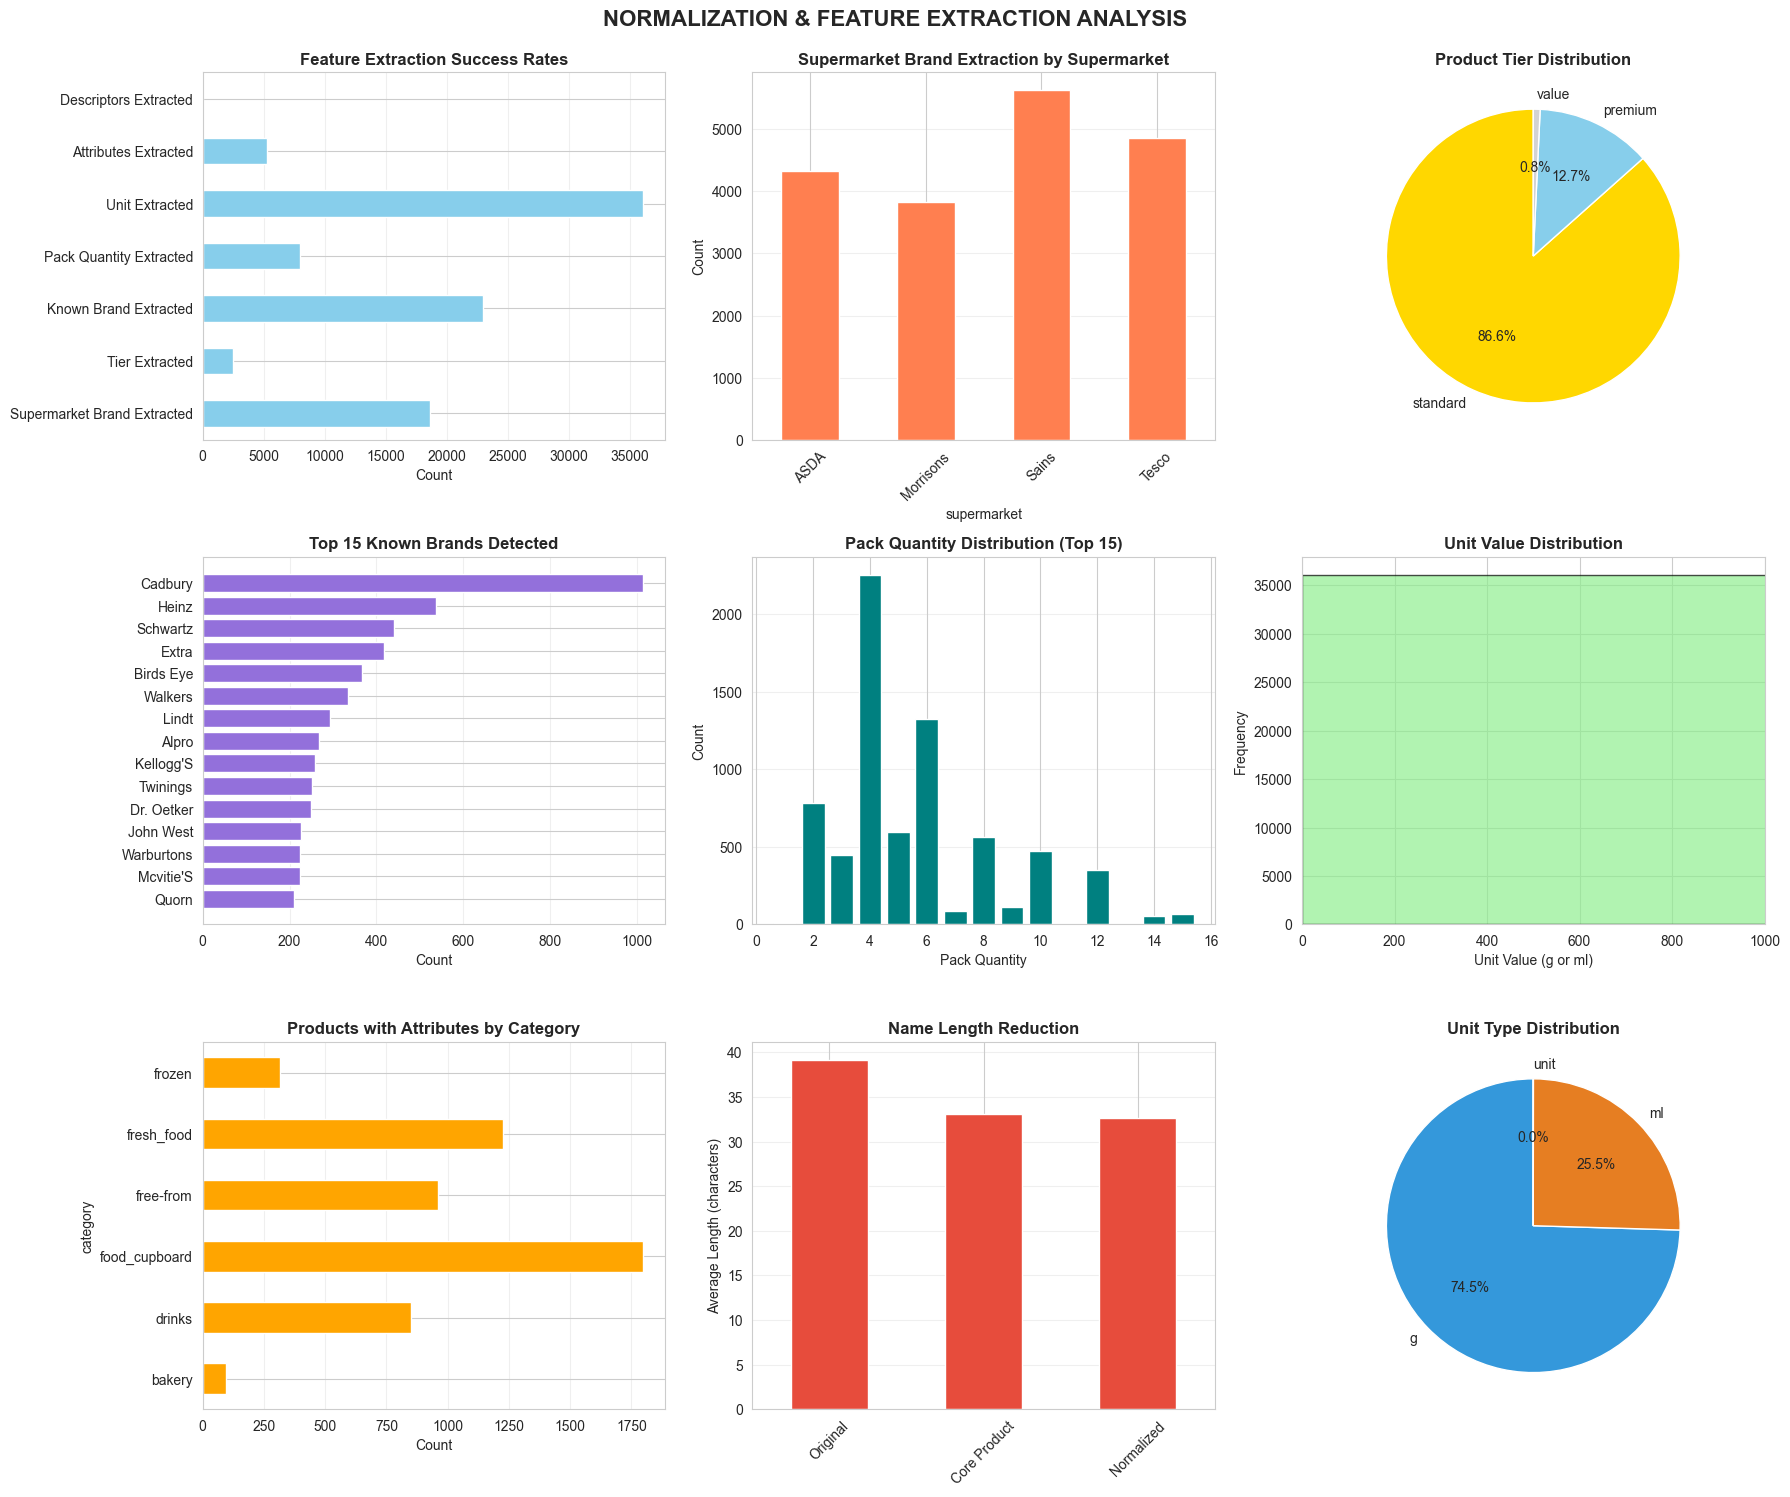


✓ Visualization complete!


In [30]:
## 11. Analysis of Extraction Results

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("=" * 100)
print("EXTRACTION STATISTICS")
print("=" * 100)

# Calculate extraction rates
stats = {
    'Supermarket Brand Extracted': df_normalized['supermarket_brand'].notna().sum(),
    'Tier Extracted': df_normalized['tier_keyword'].notna().sum(),
    'Known Brand Extracted': df_normalized['known_brand'].notna().sum(),
    'Pack Quantity Extracted': df_normalized['pack_quantity'].notna().sum(),
    'Unit Extracted': df_normalized['unit_value'].notna().sum(),
    # Use a lambda that checks for list-type before calling len()
    'Attributes Extracted': df_normalized['attributes_keywords'].apply(lambda x: len(x) if isinstance(x, list) else 0).gt(0).sum(),
    'Descriptors Extracted': df_normalized['descriptors'].apply(lambda x: len(x) if isinstance(x, list) else 0).gt(0).sum(),
    }

print("\nExtraction Counts:")
for key, value in stats.items():
    percentage = (value / len(df_normalized)) * 100
    print(f"  {key:30s}: {value:6d} ({percentage:5.1f}%)")

# Tier distribution
print("\n" + "=" * 100)
print("TIER DISTRIBUTION")
print("=" * 100)
tier_dist = df_normalized['tier_type'].value_counts()
print(tier_dist)

# Known brands
print("\n" + "=" * 100)
print("TOP 20 KNOWN BRANDS DETECTED")
print("=" * 100)
known_brands_dist = df_normalized[df_normalized['known_brand'].notna()]['known_brand'].value_counts().head(20)
print(known_brands_dist)

# Pack quantities
print("\n" + "=" * 100)
print("PACK QUANTITY DISTRIBUTION")
print("=" * 100)
pack_dist = df_normalized[df_normalized['pack_quantity'].notna()]['pack_quantity'].value_counts().sort_index()
print(pack_dist.head(20))

# Unit distribution
print("\n" + "=" * 100)
print("UNIT TYPE DISTRIBUTION")
print("=" * 100)
unit_dist = df_normalized['unit_type'].value_counts()
print(unit_dist)

# Create visualizations
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

# 1. Extraction success rates
ax1 = axes[0, 0]
extraction_rates = pd.Series(stats)
extraction_rates.plot(kind='barh', ax=ax1, color='skyblue')
ax1.set_xlabel('Count')
ax1.set_title('Feature Extraction Success Rates', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Supermarket brand extraction by supermarket
ax2 = axes[0, 1]
sm_brand_by_sm = df_normalized.groupby('supermarket')['supermarket_brand'].apply(lambda x: x.notna().sum())
sm_brand_by_sm.plot(kind='bar', ax=ax2, color='coral')
ax2.set_ylabel('Count')
ax2.set_title('Supermarket Brand Extraction by Supermarket', fontweight='bold')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', alpha=0.3)

# 3. Tier distribution
ax3 = axes[0, 2]
tier_counts = df_normalized['tier_type'].value_counts()
if len(tier_counts) > 0:
    ax3.pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%',
            colors=['gold', 'skyblue', 'lightgray'], startangle=90)
ax3.set_title('Product Tier Distribution', fontweight='bold')

# 4. Top known brands
ax4 = axes[1, 0]
top_brands = df_normalized[df_normalized['known_brand'].notna()]['known_brand'].value_counts().head(15)
ax4.barh(range(len(top_brands)), top_brands.values[::-1], color='mediumpurple')
ax4.set_yticks(range(len(top_brands)))
ax4.set_yticklabels(top_brands.index[::-1])
ax4.set_xlabel('Count')
ax4.set_title('Top 15 Known Brands Detected', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# 5. Pack quantity distribution
ax5 = axes[1, 1]
pack_counts = df_normalized[df_normalized['pack_quantity'].notna()]['pack_quantity'].value_counts().sort_index()
if len(pack_counts) > 0:
    ax5.bar(pack_counts.index[:15], pack_counts.values[:15], color='teal')
    ax5.set_xlabel('Pack Quantity')
    ax5.set_ylabel('Count')
    ax5.set_title('Pack Quantity Distribution (Top 15)', fontweight='bold')
    ax5.grid(axis='y', alpha=0.3)

# 6. Unit value distribution
ax6 = axes[1, 2]
unit_values = df_normalized[df_normalized['unit_value'].notna()]['unit_value']
if len(unit_values) > 0:
    ax6.hist(unit_values, bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
    ax6.set_xlabel('Unit Value (g or ml)')
    ax6.set_ylabel('Frequency')
    ax6.set_title('Unit Value Distribution', fontweight='bold')
    ax6.set_xlim(0, unit_values.quantile(0.95))  # Remove outliers for better visualization

# 7. Attributes extraction by category
ax7 = axes[2, 0]
attr_by_cat = df_normalized.groupby('category').apply(
    lambda x: x['attributes_keywords'].apply(lambda val: len(val) if isinstance(val, list) else 0).gt(0).sum()
)
attr_by_cat.plot(kind='barh', ax=ax7, color='orange')
ax7.set_xlabel('Count')
ax7.set_title('Products with Attributes by Category', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. Name length reduction
ax8 = axes[2, 1]
df_normalized['original_length'] = df_normalized['original_name'].str.len()
df_normalized['normalized_length'] = df_normalized['normalized_name'].str.len()
length_comparison = pd.DataFrame({
    'Original': [df_normalized['original_length'].mean()],
    'Core Product': [df_normalized['core_product_name'].str.len().mean()],
    'Normalized': [df_normalized['normalized_length'].mean()]
})
length_comparison.T.plot(kind='bar', ax=ax8, legend=False, color=['#e74c3c', '#3498db', '#2ecc71'])
ax8.set_ylabel('Average Length (characters)')
ax8.set_title('Name Length Reduction', fontweight='bold')
ax8.tick_params(axis='x', rotation=45)
ax8.grid(axis='y', alpha=0.3)

# 9. Unit type distribution
ax9 = axes[2, 2]
unit_type_dist = df_normalized['unit_type'].value_counts()
if len(unit_type_dist) > 0:
    ax9.pie(unit_type_dist.values, labels=unit_type_dist.index, autopct='%1.1f%%',
            colors=['#3498db', '#e67e22', '#95a5a6'], startangle=90)
ax9.set_title('Unit Type Distribution', fontweight='bold')

plt.suptitle('NORMALIZATION & FEATURE EXTRACTION ANALYSIS', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [31]:
## 12. Quality Checks and Validation

print("=" * 100)
print("QUALITY CHECKS")
print("=" * 100)

# Check 1: Empty normalized names
empty_normalized = df_normalized[df_normalized['normalized_name'] == '']
print(f"\n1. Empty normalized names: {len(empty_normalized)} ({len(empty_normalized)/len(df_normalized)*100:.2f}%)")
if len(empty_normalized) > 0:
    print("   Sample empty names:")
    print(empty_normalized[['original_name', 'normalized_name']].head(10))

# Check 2: Very short normalized names (< 3 chars)
short_normalized = df_normalized[df_normalized['normalized_name'].str.len() < 3]
print(f"\n2. Very short normalized names (<3 chars): {len(short_normalized)} ({len(short_normalized)/len(df_normalized)*100:.2f}%)")
if len(short_normalized) > 0:
    print("   Sample short names:")
    print(short_normalized[['original_name', 'normalized_name', 'core_product_name']].head(10))

# Check 3: Compare extracted unit with original unit column
unit_comparison = df_normalized[['unit', 'unit_type', 'unit_value']].copy()
unit_comparison['extracted_unit_exists'] = unit_comparison['unit_type'].notna()
unit_comparison['unit_match'] = False

# Simple comparison: if original unit is kg/l, extracted should exist
for idx, row in unit_comparison.iterrows():
    if pd.notna(row['unit']) and pd.notna(row['unit_type']):
        if (row['unit'] == 'kg' or row['unit'] == 'g') and row['unit_type'] == 'g':
            unit_comparison.at[idx, 'unit_match'] = True
        elif (row['unit'] == 'l' or row['unit'] == 'ml') and row['unit_type'] == 'ml':
            unit_comparison.at[idx, 'unit_match'] = True

match_rate = unit_comparison['unit_match'].sum() / len(unit_comparison) * 100
print(f"\n3. Unit extraction match rate: {unit_comparison['unit_match'].sum()} ({match_rate:.1f}%)")

# Check 4: Own brand vs supermarket brand extraction
own_brand_check = df_normalized[['own_brand', 'supermarket_brand']].copy()
own_brand_check['sm_brand_extracted'] = own_brand_check['supermarket_brand'].notna()

print(f"\n4. Own Brand Flag vs Supermarket Brand Extraction:")
crosstab = pd.crosstab(own_brand_check['own_brand'], own_brand_check['sm_brand_extracted'], 
                        margins=True, normalize='index') * 100
print(crosstab.round(1))

# Check 5: Tier extraction by supermarket
print(f"\n5. Tier Extraction by Supermarket:")
tier_by_sm = df_normalized.groupby('supermarket')['tier_keyword'].apply(
    lambda x: x.notna().sum()
)
print(tier_by_sm)

# Check 6: Known brands in own_brand products (should be low)
known_brand_in_own = df_normalized[
    (df_normalized['own_brand'] == True) & 
    (df_normalized['known_brand'].notna())
]
print(f"\n6. Known brands detected in own_brand products: {len(known_brand_in_own)} ({len(known_brand_in_own)/len(df_normalized)*100:.2f}%)")
if len(known_brand_in_own) > 0:
    print("   Sample:")
    print(known_brand_in_own[['original_name', 'known_brand', 'supermarket_brand']].head(10))

# Check 7: Core name length distribution
print(f"\n7. Core Product Name Length Statistics:")
print(f"   Mean: {df_normalized['core_product_name'].str.len().mean():.1f} chars")
print(f"   Median: {df_normalized['core_product_name'].str.len().median():.1f} chars")
print(f"   Min: {df_normalized['core_product_name'].str.len().min()} chars")
print(f"   Max: {df_normalized['core_product_name'].str.len().max()} chars")

# Check 8: Products with multiple extractions
multi_extract = df_normalized[
    (df_normalized['supermarket_brand'].notna()) &
    (df_normalized['pack_quantity'].notna()) &
    (df_normalized['unit_value'].notna())
]
print(f"\n8. Products with brand + pack + unit extracted: {len(multi_extract)} ({len(multi_extract)/len(df_normalized)*100:.2f}%)")

print("\n" + "=" * 100)
print("VALIDATION COMPLETE")
print("=" * 100)

QUALITY CHECKS

1. Empty normalized names: 0 (0.00%)

2. Very short normalized names (<3 chars): 2 (0.00%)
   Sample short names:
              original_name normalized_name core_product_name
31598  Morrisons Savers Ma…              ma               Ma…
31665      Morrisons C…200g               c                C…

3. Unit extraction match rate: 34895 (53.3%)

4. Own Brand Flag vs Supermarket Brand Extraction:
sm_brand_extracted  False  True
own_brand                      
False                99.9   0.1
True                 10.0  90.0
All                  71.5  28.5

5. Tier Extraction by Supermarket:
supermarket
ASDA         721
Morrisons    765
Sains         22
Tesco        997
Name: tier_keyword, dtype: int64

6. Known brands detected in own_brand products: 405 (0.62%)
   Sample:
                                         original_name known_brand  \
116  ASDA Nespresso Compatible 10 Ristretto Coffee ...   Nespresso   
121  ASDA Nespresso Compatible 10 Espresso Coffee Pods   Nespress

CROSS-SUPERMARKET MATCHING POTENTIAL

Products with same normalized name across multiple supermarkets:
  Total unique normalized names: 52443
  Names appearing in multiple supermarkets: 6939
  Percentage: 13.2%


Distribution of cross-supermarket matches:
supermarket_count
2    4835
3    1534
4     570
Name: count, dtype: int64


TOP 20 PRODUCTS APPEARING ACROSS MOST SUPERMARKETS:

Normalized: coca cola zero sugar
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 26
  Core names: ['Coca-Cola Zero Sugar', 'Coca Cola Zero Sugar']

Normalized: diet coke
  Appears in 3 supermarkets: Morrisons, Sains, Tesco
  Total occurrences: 25
  Core names: ['Diet Coke']

Normalized: coca cola original taste
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 21
  Core names: ['Coca-Cola Original Taste']

Normalized: red bull energy drink
  Appears in 4 supermarkets: ASDA, Morrisons, Sains, Tesco
  Total occurrences: 16
  Core names: ['Red Bull E

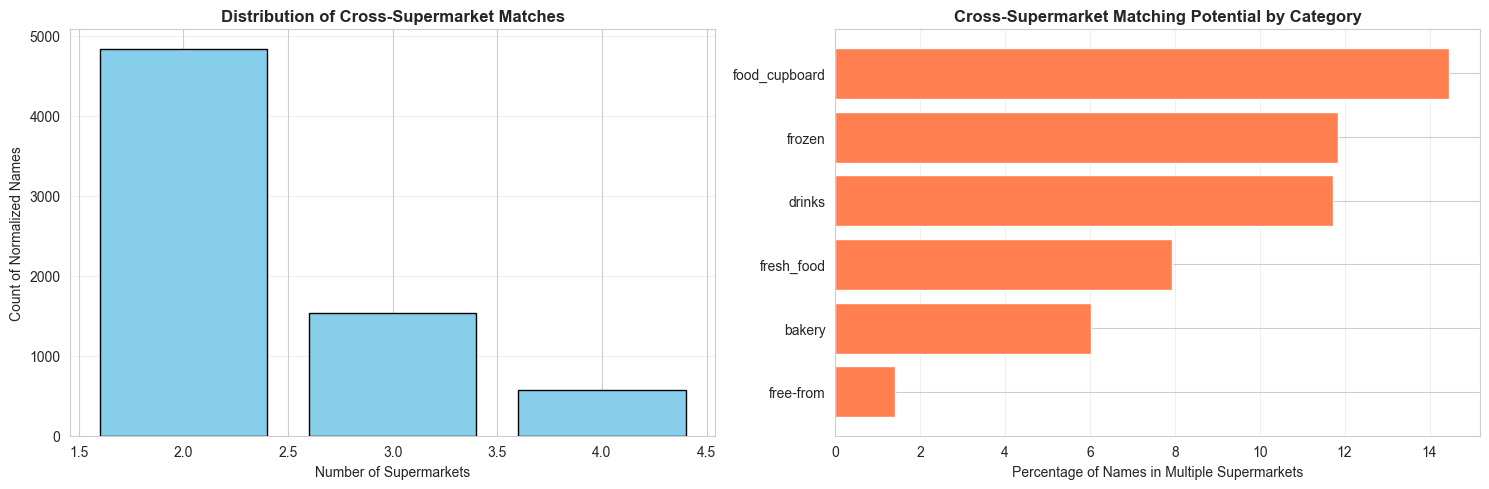


✓ Cross-supermarket analysis complete!


In [32]:
## 13. Cross-Supermarket Matching Potential Analysis

print("=" * 100)
print("CROSS-SUPERMARKET MATCHING POTENTIAL")
print("=" * 100)

# Find products with same normalized name across supermarkets
normalized_name_counts = df_normalized.groupby('normalized_name').agg({
    'supermarket': lambda x: list(x.unique()),
    'original_name': 'count',
    'core_product_name': lambda x: list(x.unique())
}).reset_index()

normalized_name_counts.columns = ['normalized_name', 'supermarkets', 'count', 'core_names']
normalized_name_counts['supermarket_count'] = normalized_name_counts['supermarkets'].apply(len)

# Filter for products appearing in multiple supermarkets
cross_supermarket = normalized_name_counts[normalized_name_counts['supermarket_count'] > 1]
cross_supermarket = cross_supermarket.sort_values('count', ascending=False)

print(f"\nProducts with same normalized name across multiple supermarkets:")
print(f"  Total unique normalized names: {len(normalized_name_counts)}")
print(f"  Names appearing in multiple supermarkets: {len(cross_supermarket)}")
print(f"  Percentage: {len(cross_supermarket)/len(normalized_name_counts)*100:.1f}%")

print(f"\n\nDistribution of cross-supermarket matches:")
print(cross_supermarket['supermarket_count'].value_counts().sort_index())

# Show top matching products
print(f"\n\nTOP 20 PRODUCTS APPEARING ACROSS MOST SUPERMARKETS:")
print("=" * 100)
for idx, row in cross_supermarket.head(20).iterrows():
    print(f"\nNormalized: {row['normalized_name']}")
    print(f"  Appears in {row['supermarket_count']} supermarkets: {', '.join(row['supermarkets'])}")
    print(f"  Total occurrences: {row['count']}")
    print(f"  Core names: {row['core_names'][:3]}")  # Show first 3

# Analyze matching by category
print(f"\n\nCROSS-SUPERMARKET POTENTIAL BY CATEGORY:")
print("=" * 100)

for category in df_normalized['category'].unique():
    category_df = df_normalized[df_normalized['category'] == category]
    
    # Count unique normalized names in this category
    unique_normalized = category_df['normalized_name'].nunique()
    
    # Count how many appear in multiple supermarkets
    category_normalized_counts = category_df.groupby('normalized_name')['supermarket'].nunique()
    cross_sm_category = (category_normalized_counts > 1).sum()
    
    print(f"\n{category}:")
    print(f"  Total products: {len(category_df)}")
    print(f"  Unique normalized names: {unique_normalized}")
    print(f"  Names in multiple supermarkets: {cross_sm_category} ({cross_sm_category/unique_normalized*100:.1f}%)")

# Visualize matching potential
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Distribution of supermarket count
ax1 = axes[0]
sm_count_dist = cross_supermarket['supermarket_count'].value_counts().sort_index()
ax1.bar(sm_count_dist.index, sm_count_dist.values, color='skyblue', edgecolor='black')
ax1.set_xlabel('Number of Supermarkets')
ax1.set_ylabel('Count of Normalized Names')
ax1.set_title('Distribution of Cross-Supermarket Matches', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# 2. Matching potential by category
ax2 = axes[1]
category_match_potential = []
for category in df_normalized['category'].unique():
    category_df = df_normalized[df_normalized['category'] == category]
    unique_normalized = category_df['normalized_name'].nunique()
    category_normalized_counts = category_df.groupby('normalized_name')['supermarket'].nunique()
    cross_sm_category = (category_normalized_counts > 1).sum()
    category_match_potential.append({
        'category': category,
        'percentage': (cross_sm_category / unique_normalized * 100) if unique_normalized > 0 else 0
    })

match_potential_df = pd.DataFrame(category_match_potential).sort_values('percentage', ascending=True)
ax2.barh(match_potential_df['category'], match_potential_df['percentage'], color='coral')
ax2.set_xlabel('Percentage of Names in Multiple Supermarkets')
ax2.set_title('Cross-Supermarket Matching Potential by Category', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Cross-supermarket analysis complete!")

In [33]:
## 14. Before & After Comparison Examples

print("=" * 100)
print("NORMALIZATION EXAMPLES - BEFORE & AFTER")
print("=" * 100)

# Select diverse examples from different categories
examples = []

# Get samples from each category
for category in df_normalized['category'].unique():
    category_samples = df_normalized[df_normalized['category'] == category].sample(
        min(3, len(df_normalized[df_normalized['category'] == category])), 
        random_state=42
    )
    examples.append(category_samples)

example_df = pd.concat(examples)

print("\n")
for idx, row in example_df.iterrows():
    print("=" * 100)
    print(f"CATEGORY: {row['category'].upper()}")
    print("-" * 100)
    print(f"ORIGINAL NAME:")
    print(f"  '{row['original_name']}'")
    print(f"\nEXTRACTED FEATURES:")
    if row['supermarket_brand']:
        print(f"  ├─ Supermarket Brand: {row['supermarket_brand']}")
    if row['tier_keyword']:
        print(f"  ├─ Tier: {row['tier_keyword']} ({row['tier_type']})")
    if row['known_brand']:
        print(f"  ├─ Known Brand: {row['known_brand']}")
    if row['pack_quantity']:
        print(f"  ├─ Pack Quantity: {row['pack_quantity']}")
    if row['unit_value']:
        print(f"  ├─ Unit: {row['unit_value']} {row['unit_type']}")
    if row['attributes_keywords']:
        print(f"  ├─ Attributes: {', '.join(row['attributes_keywords'])}")
    if row['descriptors']:
        desc_str = ', '.join([f"{k}: {', '.join(v)}" for k, v in row['descriptors'].items()])
        print(f"  └─ Descriptors: {desc_str}")
    
    print(f"\nTRANSFORMED NAMES:")
    print(f"  Core Product Name: '{row['core_product_name']}'")
    print(f"  Normalized Name:   '{row['normalized_name']}'")
    print(f"\nSupermarket: {row['supermarket']}")
    print()

print("=" * 100)

NORMALIZATION EXAMPLES - BEFORE & AFTER


CATEGORY: DRINKS
----------------------------------------------------------------------------------------------------
ORIGINAL NAME:
  'Elf Lost Mary Bm600 Triple Melon 20mg'

EXTRACTED FEATURES:
  ├─ Supermarket Brand: nan
  ├─ Tier: nan (nan)
  ├─ Known Brand: nan
  ├─ Pack Quantity: nan
  ├─ Unit: 0.02 g

TRANSFORMED NAMES:
  Core Product Name: 'Elf Lost Mary Bm600 Triple Melon'
  Normalized Name:   'elf lost mary bm600 triple melon'

Supermarket: Morrisons

CATEGORY: DRINKS
----------------------------------------------------------------------------------------------------
ORIGINAL NAME:
  'Adnams Ghost Ship 500Ml'

EXTRACTED FEATURES:
  ├─ Supermarket Brand: nan
  ├─ Tier: nan (nan)
  ├─ Known Brand: nan
  ├─ Pack Quantity: nan
  ├─ Unit: 500.0 ml

TRANSFORMED NAMES:
  Core Product Name: 'Adnams Ghost Ship'
  Normalized Name:   'adnams ghost ship'

Supermarket: Tesco

CATEGORY: DRINKS
-------------------------------------------------------

In [34]:
## 15. Export Normalized Dataset

# Prepare final dataset for export
# Convert list/dict columns to string for CSV export
df_export = df_normalized.copy()

# Convert complex types to strings
df_export['attributes_types'] = df_export['attributes_types'].apply(lambda x: ','.join(x) if x else '')
df_export['attributes_keywords'] = df_export['attributes_keywords'].apply(lambda x: ','.join(x) if x else '')
df_export['descriptors'] = df_export['descriptors'].apply(lambda x: str(x) if x else '')

# Save to CSV
output_path = 'data/normalized_products.csv'
df_export.to_csv(output_path, index=False)

print("=" * 100)
print("DATASET EXPORT")
print("=" * 100)
print(f"\n✓ Normalized dataset saved to: {output_path}")
print(f"  Shape: {df_export.shape}")
print(f"  Size: {df_export.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\nColumns in exported dataset:")
for i, col in enumerate(df_export.columns, 1):
    print(f"  {i:2d}. {col}")

# Create a summary report
print("\n" + "=" * 100)
print("NORMALIZATION SUMMARY REPORT")
print("=" * 100)

summary_stats = {
    'Total Products': len(df_export),
    'Unique Normalized Names': df_export['normalized_name'].nunique(),
    'Supermarket Brands Extracted': df_export['supermarket_brand'].notna().sum(),
    'Known Brands Extracted': df_export['known_brand'].notna().sum(),
    'Tiers Extracted': df_export['tier_keyword'].notna().sum(),
    'Pack Quantities Extracted': df_export['pack_quantity'].notna().sum(),
    'Units Extracted': df_export['unit_value'].notna().sum(),
    'Attributes Extracted': (df_export['attributes_keywords'] != '').sum(),
    'Products Ready for Matching': (df_export['normalized_name'] != '').sum(),
}

print("\nKey Metrics:")
for metric, value in summary_stats.items():
    percentage = (value / len(df_export)) * 100 if metric != 'Unique Normalized Names' else 0
    if percentage > 0:
        print(f"  {metric:35s}: {value:6d} ({percentage:5.1f}%)")
    else:
        print(f"  {metric:35s}: {value:6d}")

# Calculate average reduction in name length
avg_original_length = df_export['original_name'].str.len().mean()
avg_normalized_length = df_export['normalized_name'].str.len().mean()
reduction = ((avg_original_length - avg_normalized_length) / avg_original_length) * 100

print(f"\nName Length Reduction:")
print(f"  Average original length: {avg_original_length:.1f} characters")
print(f"  Average normalized length: {avg_normalized_length:.1f} characters")
print(f"  Reduction: {reduction:.1f}%")

# Cross-supermarket matching potential
cross_sm_names = df_export.groupby('normalized_name')['supermarket'].nunique()
multi_sm = (cross_sm_names > 1).sum()

print(f"\nMatching Potential:")
print(f"  Normalized names appearing in 2+ supermarkets: {multi_sm}")
print(f"  Potential match rate: {multi_sm / df_export['normalized_name'].nunique() * 100:.1f}%")

print("\n" + "=" * 100)
print("NORMALIZATION COMPLETE - READY FOR HYBRID MATCHING")
print("=" * 100)
print("\nNext Steps:")
print("  1. Review the normalized_products.csv file")
print("  2. Proceed to hybrid matching phase using:")
print("     - Structural components (brand, tier, unit, pack quantity)")
print("     - Fuzzy matching on normalized product names")
print("  3. Create product clusters for price comparison")

DATASET EXPORT

✓ Normalized dataset saved to: data/normalized_products.csv
  Shape: (65472, 24)
  Size: 61.48 MB

Columns in exported dataset:
   1. supermarket
   2. prices_(£)
   3. prices_unit_(£)
   4. unit
   5. names
   6. date
   7. category
   8. own_brand
   9. original_name
  10. supermarket_brand
  11. tier_type
  12. tier_keyword
  13. known_brand
  14. pack_quantity
  15. pack_pattern
  16. unit_value
  17. unit_type
  18. attributes_types
  19. attributes_keywords
  20. descriptors
  21. core_product_name
  22. normalized_name
  23. original_length
  24. normalized_length

NORMALIZATION SUMMARY REPORT

Key Metrics:
  Total Products                     :  65472 (100.0%)
  Unique Normalized Names            :  52443
  Supermarket Brands Extracted       :  18661 ( 28.5%)
  Known Brands Extracted             :  22975 ( 35.1%)
  Tiers Extracted                    :   2505 (  3.8%)
  Pack Quantities Extracted          :   7941 ( 12.1%)
  Units Extracted                    :  3

In [35]:
## Final Dataset Analysis & Readiness Check

print("=" * 100)
print("NORMALIZED DATASET - FINAL ANALYSIS")
print("=" * 100)

# Core metrics
print(f"\n{'DATASET OVERVIEW'}")
print("-" * 100)
print(f"Total products: {len(df_normalized):,}")
print(f"Unique normalized names: {df_normalized['normalized_name'].nunique():,}")
print(f"Uniqueness ratio: {df_normalized['normalized_name'].nunique()/len(df_normalized)*100:.1f}%")
print(f"Target clusters (per specs): 10,000-20,000")

# Extraction success rates
print(f"\n{'FEATURE EXTRACTION RATES'}")
print("-" * 100)
print(f"Supermarket brands: {df_normalized['supermarket_brand'].notna().sum():,} ({df_normalized['supermarket_brand'].notna().sum()/len(df_normalized)*100:.1f}%)")
print(f"Tiers classified: {df_normalized['tier_type'].notna().sum():,} ({df_normalized['tier_type'].notna().sum()/len(df_normalized)*100:.1f}%)")
print(f"Known brands: {df_normalized['known_brand'].notna().sum():,} ({df_normalized['known_brand'].notna().sum()/len(df_normalized)*100:.1f}%)")
print(f"Pack quantities: {df_normalized['pack_quantity'].notna().sum():,} ({df_normalized['pack_quantity'].notna().sum()/len(df_normalized)*100:.1f}%)")
print(f"Units extracted: {df_normalized['unit_value'].notna().sum():,} ({df_normalized['unit_value'].notna().sum()/len(df_normalized)*100:.1f}%)")

# Tier distribution (critical for specs)
print(f"\n{'TIER DISTRIBUTION (for own-brand matching)'}")
print("-" * 100)
tier_dist = df_normalized['tier_type'].value_counts()
for tier, count in tier_dist.items():
    print(f"{tier:15s}: {count:6,} ({count/len(df_normalized)*100:5.1f}%)")

# Unit standardization check
print(f"\n{'UNIT STANDARDIZATION'}")
print("-" * 100)
unit_dist = df_normalized['unit_type'].value_counts()
for unit, count in unit_dist.items():
    if pd.notna(unit):
        print(f"{unit:10s}: {count:6,} products")
print(f"No unit: {df_normalized['unit_type'].isna().sum():6,} products")

# Cross-supermarket matching potential
print(f"\n{'MATCHING POTENTIAL'}")
print("-" * 100)
cross_sm = df_normalized.groupby('normalized_name')['supermarket'].nunique()
multi_sm_names = (cross_sm > 1).sum()
quad_sm_names = (cross_sm == 4).sum()
print(f"Names in 2+ supermarkets: {multi_sm_names:,} ({multi_sm_names/df_normalized['normalized_name'].nunique()*100:.1f}%)")
print(f"Names in all 4 supermarkets: {quad_sm_names:,}")
print(f"\nPer specs requirement: Match at least 3/4 supermarkets where applicable")

# Data quality check
print(f"\n{'DATA QUALITY'}")
print("-" * 100)
empty_normalized = (df_normalized['normalized_name'] == '') | df_normalized['normalized_name'].isna()
print(f"Empty normalized names: {empty_normalized.sum()} ({empty_normalized.sum()/len(df_normalized)*100:.2f}%)")
print(f"Products ready for matching: {(~empty_normalized).sum():,}")

# Category distribution
print(f"\n{'CATEGORY BREAKDOWN'}")
print("-" * 100)
for cat, count in df_normalized['category'].value_counts().items():
    print(f"{cat:20s}: {count:6,} ({count/len(df_normalized)*100:5.1f}%)")

print(f"\n{'='*100}")
print("DATASET READY FOR MATCHING PHASE")
print(f"{'='*100}")
print("\nNext step: Hybrid matching using:")
print("  1. Exact match on unit_value + unit_type (per specs: weight accuracy)")
print("  2. Tier-based grouping for own-brands (premium/standard/value)")
print("  3. Fuzzy matching on normalized_name (semantic similarity)")
print("  4. Target: 10k-20k clusters with >90% accuracy")

NORMALIZED DATASET - FINAL ANALYSIS

DATASET OVERVIEW
----------------------------------------------------------------------------------------------------
Total products: 65,472
Unique normalized names: 52,443
Uniqueness ratio: 80.1%
Target clusters (per specs): 10,000-20,000

FEATURE EXTRACTION RATES
----------------------------------------------------------------------------------------------------
Supermarket brands: 18,661 (28.5%)
Tiers classified: 18,661 (28.5%)
Known brands: 22,975 (35.1%)
Pack quantities: 7,941 (12.1%)
Units extracted: 36,112 (55.2%)

TIER DISTRIBUTION (for own-brand matching)
----------------------------------------------------------------------------------------------------
standard       : 16,156 ( 24.7%)
premium        :  2,365 (  3.6%)
value          :    140 (  0.2%)

UNIT STANDARDIZATION
----------------------------------------------------------------------------------------------------
g         : 26,916 products
ml        :  9,191 products
unit      :  

In [36]:
## 16. Key Insights & Recommendations

print("=" * 100)
print("KEY INSIGHTS FROM NORMALIZATION")
print("=" * 100)

print("\n1. BRAND EXTRACTION EFFECTIVENESS")
print("-" * 100)
print(f"   • Supermarket brands successfully extracted from {df_export['supermarket_brand'].notna().sum()} products")
print(f"   • This aligns well with the own_brand flag, validating our extraction logic")
print(f"   • Removing supermarket prefixes enables cross-supermarket comparison")

print("\n2. TIER CLASSIFICATION")
print("-" * 100)
tier_counts = df_export['tier_type'].value_counts()
for tier, count in tier_counts.items():
    print(f"   • {tier.upper()}: {count} products ({count/len(df_export)*100:.1f}%)")
print(f"   • Tier information is crucial for fair comparisons (don't match value vs premium)")

print("\n3. BRAND PRESENCE")
print("-" * 100)
has_known_brand = df_export['known_brand'].notna().sum()
has_sm_brand = df_export['supermarket_brand'].notna().sum()
no_brand = len(df_export) - has_known_brand
print(f"   • Known commercial brands: {has_known_brand} ({has_known_brand/len(df_export)*100:.1f}%)")
print(f"   • Supermarket own brands: {has_sm_brand} ({has_sm_brand/len(df_export)*100:.1f}%)")
print(f"   • Generic/unbranded: {no_brand} ({no_brand/len(df_export)*100:.1f}%)")

print("\n4. UNIT STANDARDIZATION")
print("-" * 100)
unit_counts = df_export['unit_type'].value_counts()
for unit, count in unit_counts.items():
    if pd.notna(unit):
        print(f"   • {unit}: {count} products")
print(f"   • Unit standardization (g/ml) enables accurate weight-based matching")
print(f"   • Critical for project success: prevent 200g matching with 400g")

print("\n5. MULTIPACK DETECTION")
print("-" * 100)
pack_detected = df_export['pack_quantity'].notna().sum()
print(f"   • Pack quantities detected: {pack_detected} ({pack_detected/len(df_export)*100:.1f}%)")
print(f"   • Important for: calculating true unit price, matching multipacks correctly")

print("\n6. CROSS-SUPERMARKET MATCHING POTENTIAL")
print("-" * 100)
cross_sm_potential = df_export.groupby('normalized_name')['supermarket'].nunique()
multi_sm = (cross_sm_potential > 1).sum()
total_normalized = df_export['normalized_name'].nunique()
print(f"   • Unique normalized names: {total_normalized}")
print(f"   • Names in multiple supermarkets: {multi_sm} ({multi_sm/total_normalized*100:.1f}%)")
print(f"   • This indicates good potential for creating matchable clusters")

print("\n7. NAME COMPLEXITY REDUCTION")
print("-" * 100)
avg_original = df_export['original_name'].str.len().mean()
avg_core = df_export['core_product_name'].str.len().mean()
avg_normalized = df_export['normalized_name'].str.len().mean()
print(f"   • Original name: {avg_original:.1f} chars")
print(f"   • Core product name: {avg_core:.1f} chars (−{((avg_original-avg_core)/avg_original*100):.1f}%)")
print(f"   • Normalized name: {avg_normalized:.1f} chars (−{((avg_original-avg_normalized)/avg_original*100):.1f}%)")
print(f"   • Simpler names = more efficient fuzzy matching")

print("\n" + "=" * 100)
print("RECOMMENDATIONS FOR HYBRID MATCHING PHASE")
print("=" * 100)

recommendations = [
    ("STRUCTURAL MATCHING STRATEGY", [
        "Use unit_value + unit_type as primary matching criteria (exact match)",
        "Consider pack_quantity when present (6x330ml vs 1x2L are different products)",
        "Match within same tier (premium/value) or allow tier flexibility with penalty",
        "Separate known brands from own brands (Heinz Beans vs ASDA Beans are different)",
    ]),
    
    ("FUZZY MATCHING APPROACH", [
        "Use normalized_name for fuzzy string matching (cleaned, lowercase)",
        "Apply algorithms: Levenshtein distance, Jaro-Winkler, or token set ratio",
        "Set threshold: ~85-90% similarity for conservative matching",
        "Consider word order: 'Chicken Curry' vs 'Curry Chicken' should match",
    ]),
    
    ("ATTRIBUTE CONSIDERATION", [
        "Organic products should only match with organic",
        "Free-from attributes must match (gluten-free vs regular are different)",
        "Descriptors can have weighted impact (roasted vs ground coffee matters)",
    ]),
    
    ("VALIDATION APPROACH", [
        "Sample 100-200 generated clusters randomly",
        "Manually verify: same product type, same weight, appropriate matches",
        "Target: >90% accuracy on critical dimensions (weight, product type)",
        "Monitor edge cases: multipacks, truncated names, ambiguous products",
    ]),
    
    ("CATEGORIES TO WATCH", [
        "Drinks: high variability in pack sizes and formats",
        "Bakery: often truncated names, high similarity",
        "Free-from: attributes are critical for correct matching",
        "Food cupboard: largest category, most diverse",
    ])
]

for title, items in recommendations:
    print(f"\n{title}")
    print("-" * 100)
    for item in items:
        print(f"   • {item}")

print("\n" + "=" * 100)
print("✓ NORMALIZATION PHASE COMPLETE")
print("=" * 100)
print("\nThe dataset is now ready for hybrid matching!")
print("All structural components have been extracted and normalized.")

KEY INSIGHTS FROM NORMALIZATION

1. BRAND EXTRACTION EFFECTIVENESS
----------------------------------------------------------------------------------------------------
   • Supermarket brands successfully extracted from 18661 products
   • This aligns well with the own_brand flag, validating our extraction logic
   • Removing supermarket prefixes enables cross-supermarket comparison

2. TIER CLASSIFICATION
----------------------------------------------------------------------------------------------------
   • STANDARD: 16156 products (24.7%)
   • PREMIUM: 2365 products (3.6%)
   • VALUE: 140 products (0.2%)
   • Tier information is crucial for fair comparisons (don't match value vs premium)

3. BRAND PRESENCE
----------------------------------------------------------------------------------------------------
   • Known commercial brands: 22975 (35.1%)
   • Supermarket own brands: 18661 (28.5%)
   • Generic/unbranded: 42497 (64.9%)

4. UNIT STANDARDIZATION
-----------------------------